# 02b — Merge Dataset
**Resume Classification — Deep Learning Project**

Notebook ini menggabungkan dataset asli dengan ResumeAtlas untuk memperkaya data training.

---
**Input  :**
- `data/raw/df_dataset_Resume_cleaned.csv` (dataset asli — 9 kelas IT)
- `ahmedheakl/resume-atlas` via HuggingFace (43 kelas)

**Output :** `data/processed/train.pkl`, `val.pkl`, `test.pkl`, `label_encoder.pkl` (menggantikan output dari 02_preprocessing.ipynb)

---
### Strategi
Petakan kategori yang overlap antara kedua dataset, gabungkan datanya, lalu re-encode label. Kelas yang tidak punya padanan di ResumeAtlas tetap dipertahankan sebagai kelas sendiri.

## 1. Setup & Import

In [1]:
import pandas as pd
import numpy as np
import re
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

RAW_PATH      = '../data/raw/df_dataset_Resume_cleaned.csv'
PROCESSED_DIR = '../data/processed/'
RANDOM_STATE  = 42

os.makedirs(PROCESSED_DIR, exist_ok=True)
print('Setup selesai!')

C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup selesai!


## 2. Load Kedua Dataset

In [2]:
# ── Dataset asli ─────────────────────────────────────────────
df_orig = pd.read_csv(RAW_PATH)
df_orig = df_orig[['category', 'Text']].rename(columns={'Text': 'text'})
df_orig['source'] = 'original'

print(f'Dataset asli     : {len(df_orig):,} baris | {df_orig["category"].nunique()} kelas')
print(df_orig['category'].value_counts().to_string())

Dataset asli     : 6,844 baris | 9 kelas
category
Datawarehousing, ETL, Informatica Resumes         894
SQL Developers Resumes                            795
Network and Systems Administrators Resumes        779
Business Intelligence, Business Object Resumes    769
Project Manager Resumes                           757
Business Analyst (BA) Resumes                     751
Web Developer Resumes                             731
Recruiter Resumes                                 728
Java Developers/Architects Resumes                640


In [3]:
# ── ResumeAtlas dari HuggingFace ─────────────────────────────
# Download otomatis, di-cache setelah pertama kali
print('Downloading ResumeAtlas dari HuggingFace...')
ds = load_dataset('ahmedheakl/resume-atlas')
df_atlas = ds['train'].to_pandas()
df_atlas = df_atlas[['Category', 'Text']].rename(columns={'Category': 'category', 'Text': 'text'})
df_atlas['source'] = 'resume_atlas'

print(f'\nResumeAtlas      : {len(df_atlas):,} baris | {df_atlas["category"].nunique()} kelas')
print(df_atlas['category'].value_counts().to_string())

c:\Users\ASUS\anaconda3\envs\gpu_env\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\datasets--ahmedheakl--resume-atlas. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 100%|██████████| 13389/13389 [00:00<00:00, 27993.23 examples/s]



ResumeAtlas      : 13,389 baris | 43 kelas
category
Education                    410
Mechanical Engineer          384
Electrical Engineering       384
Consultant                   368
Civil Engineer               364
Sales                        364
Management                   361
Human Resources              360
Digital Media                358
Accountant                   350
Java Developer               348
Building and Construction    345
Operations Manager           345
Architecture                 344
Testing                      344
Business Analyst             340
Aviation                     340
Finance                      339
SQL Developer                338
Public Relations             337
Health and Fitness           332
Arts                         332
Network Security Engineer    330
DotNet Developer             329
Apparel                      320
Banking                      314
Automobile                   313
Web Designing                309
SAP Developer          

## 3. Category Mapping
Petakan kategori dataset asli ke nama kategori ResumeAtlas yang setara. Kategori yang tidak ada padanannya dipertahankan apa adanya.

In [4]:
# Lihat dulu semua kategori ResumeAtlas untuk referensi
print('=== SEMUA KATEGORI RESUMEATLAS ===')
for cat in sorted(df_atlas['category'].unique()):
    count = (df_atlas['category'] == cat).sum()
    print(f'  {cat:40s} ({count} sampel)')

=== SEMUA KATEGORI RESUMEATLAS ===
  Accountant                               (350 sampel)
  Advocate                                 (291 sampel)
  Agriculture                              (293 sampel)
  Apparel                                  (320 sampel)
  Architecture                             (344 sampel)
  Arts                                     (332 sampel)
  Automobile                               (313 sampel)
  Aviation                                 (340 sampel)
  BPO                                      (203 sampel)
  Banking                                  (314 sampel)
  Blockchain                               (47 sampel)
  Building and Construction                (345 sampel)
  Business Analyst                         (340 sampel)
  Civil Engineer                           (364 sampel)
  Consultant                               (368 sampel)
  Data Science                             (299 sampel)
  Database                                 (257 sampel)
  Designing   

In [5]:
# ── Mapping kategori dataset asli → nama standar ─────────────
# Kategori yang ada padanannya di ResumeAtlas → diseragamkan
# Kategori tanpa padanan → nama baru yang konsisten

ORIG_CATEGORY_MAP = {
    # Ada padanan di ResumeAtlas → seragamkan ke nama ResumeAtlas
    'Java Developers/Architects Resumes'               : 'Java Developer',
    'Web Developer Resumes'                            : 'Web Developer',
    'SQL Developers Resumes'                           : 'Database Administrator',
    'Network and Systems Administrators Resumes'        : 'Network Engineer',
    'Project Manager Resumes'                          : 'Project Manager',
    'Business Analyst (BA) Resumes'                    : 'Business Analyst',
    'Recruiter Resumes'                                : 'HR Manager',

    # Tidak ada padanan di ResumeAtlas → buat nama baru yang bersih
    'Business Intelligence, Business Object Resumes'   : 'Business Intelligence',
    'Datawarehousing, ETL, Informatica Resumes'        : 'Data Engineer',
}

# Terapkan mapping ke dataset asli
df_orig['category'] = df_orig['category'].map(ORIG_CATEGORY_MAP)

# Verifikasi tidak ada yang null (mapping harus lengkap)
null_cats = df_orig['category'].isnull().sum()
if null_cats > 0:
    print(f'⚠ Ada {null_cats} kategori yang tidak termapping! Cek ORIG_CATEGORY_MAP.')
else:
    print('✓ Semua kategori berhasil di-mapping.')

print()
print('Kategori dataset asli setelah mapping:')
print(df_orig['category'].value_counts().to_string())

✓ Semua kategori berhasil di-mapping.

Kategori dataset asli setelah mapping:
category
Data Engineer             894
Database Administrator    795
Network Engineer          779
Business Intelligence     769
Project Manager           757
Business Analyst          751
Web Developer             731
HR Manager                728
Java Developer            640


In [6]:
# Verifikasi: kategori baru dari dataset asli yang overlap dengan ResumeAtlas
orig_cats  = set(df_orig['category'].unique())
atlas_cats = set(df_atlas['category'].unique())

overlap    = orig_cats & atlas_cats
only_orig  = orig_cats - atlas_cats

print(f'Kategori overlap (akan digabung datanya) : {len(overlap)}')
for c in sorted(overlap):
    n_orig  = (df_orig['category'] == c).sum()
    n_atlas = (df_atlas['category'] == c).sum()
    print(f'  {c:35s} orig={n_orig:4d} | atlas={n_atlas:4d} | total={n_orig+n_atlas:4d}')

print()
print(f'Kategori eksklusif dari dataset asli (kelas baru) : {len(only_orig)}')
for c in sorted(only_orig):
    print(f'  {c}')

Kategori overlap (akan digabung datanya) : 2
  Business Analyst                    orig= 751 | atlas= 340 | total=1091
  Java Developer                      orig= 640 | atlas= 348 | total= 988

Kategori eksklusif dari dataset asli (kelas baru) : 7
  Business Intelligence
  Data Engineer
  Database Administrator
  HR Manager
  Network Engineer
  Project Manager
  Web Developer


## 4. Cleaning Teks

In [8]:
def clean_text(text: str) -> str:
    """Sama persis dengan fungsi di 02_preprocessing.ipynb."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = text.encode('ascii', errors='ignore').decode()
    text = re.sub(r"[^a-zA-Z0-9'\s]", ' ', text)
    text = re.sub(r'\b\d+\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


print('Cleaning dataset asli...')
df_orig['clean_text'] = df_orig['text'].apply(clean_text)

print('Cleaning ResumeAtlas...')
df_atlas['clean_text'] = df_atlas['text'].apply(clean_text)

# Hapus baris dengan teks kosong setelah cleaning
df_orig  = df_orig[df_orig['clean_text'].str.strip() != ''].reset_index(drop=True)
df_atlas = df_atlas[df_atlas['clean_text'].str.strip() != ''].reset_index(drop=True)

print(f'Selesai! Orig: {len(df_orig):,} | Atlas: {len(df_atlas):,}')

Cleaning dataset asli...
Cleaning ResumeAtlas...
Selesai! Orig: 6,844 | Atlas: 13,389


## 5. Merge

In [9]:
# Ambil kolom yang dibutuhkan dari masing-masing
df_orig_final  = df_orig[['category', 'clean_text', 'source']]
df_atlas_final = df_atlas[['category', 'clean_text', 'source']]

# Gabungkan
df_merged = pd.concat([df_orig_final, df_atlas_final], ignore_index=True)

print(f'Total setelah merge : {len(df_merged):,} baris')
print(f'Total kelas         : {df_merged["category"].nunique()}')
print()
print('Distribusi sumber:')
print(df_merged['source'].value_counts())

Total setelah merge : 20,233 baris
Total kelas         : 50

Distribusi sumber:
source
resume_atlas    13389
original         6844
Name: count, dtype: int64


In [10]:
# Hapus duplikat teks (bisa terjadi kalau ada resume yang sama di dua sumber)
n_before = len(df_merged)
df_merged = df_merged.drop_duplicates(subset='clean_text', keep='first').reset_index(drop=True)
n_after   = len(df_merged)

print(f'Duplikat dihapus    : {n_before - n_after:,} baris')
print(f'Total bersih        : {n_after:,} baris')

Duplikat dihapus    : 2,597 baris
Total bersih        : 17,636 baris


In [11]:
# Distribusi kategori setelah merge
cat_counts = df_merged['category'].value_counts()
print('Distribusi kategori final:')
print(cat_counts.to_string())

Distribusi kategori final:
category
Business Analyst             877
Data Engineer                874
Database Administrator       740
Java Developer               715
Business Intelligence        690
Web Developer                683
Network Engineer             655
Project Manager              634
Education                    388
Electrical Engineering       359
Consultant                   342
Sales                        342
Digital Media                340
Accountant                   337
Building and Construction    335
Mechanical Engineer          335
Finance                      330
Aviation                     326
Operations Manager           326
Testing                      322
Management                   320
Apparel                      316
HR Manager                   311
Public Relations             307
Civil Engineer               307
Network Security Engineer    306
Architecture                 305
Human Resources              303
Automobile                   302
Health 

## 6. Tangani Class Imbalance
Setelah merge, beberapa kelas mungkin jauh lebih banyak dari yang lain. Kita batasi maksimum per kelas agar training tidak bias.

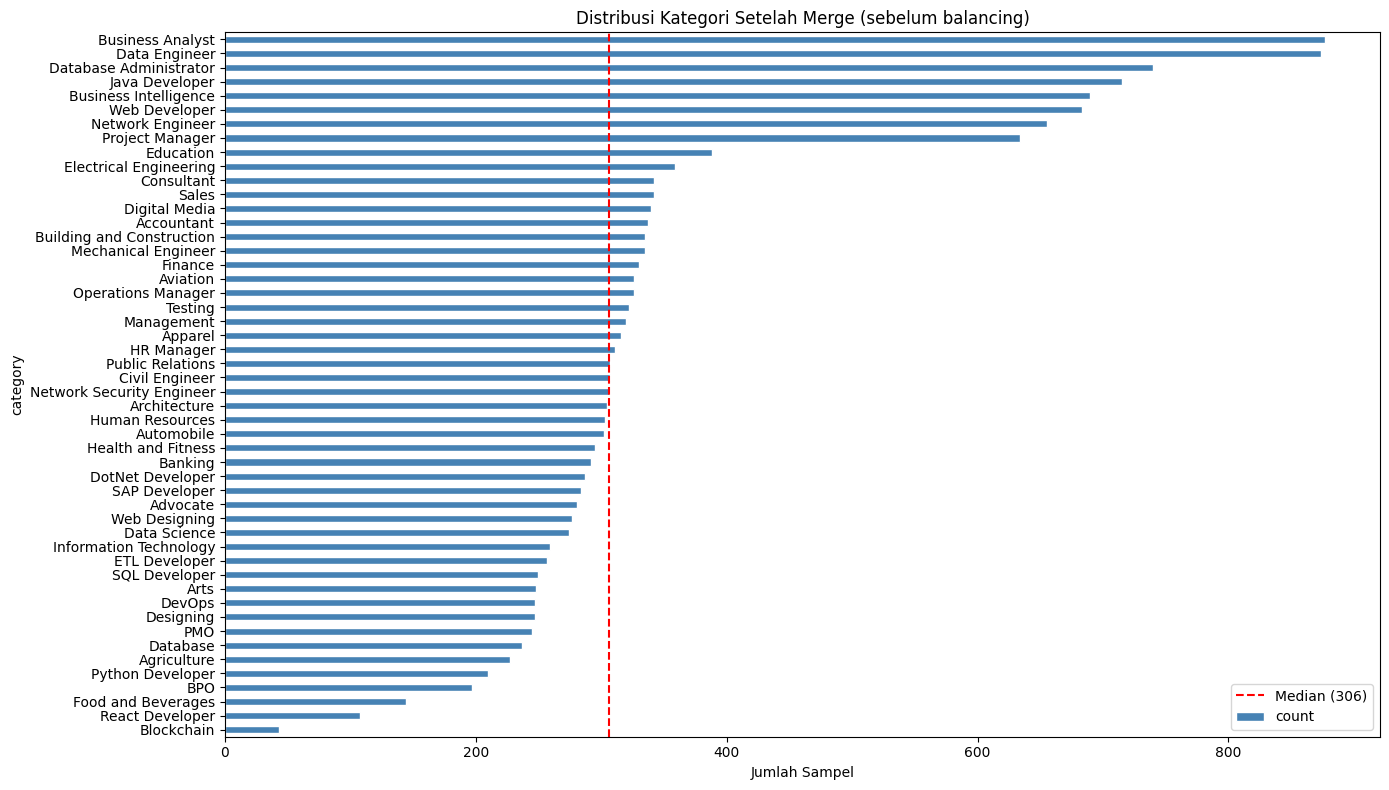

Min sampel per kelas : 43
Max sampel per kelas : 877
Median               : 306


In [12]:
# Visualisasi distribusi sebelum balancing
fig, ax = plt.subplots(figsize=(14, 8))
cat_counts.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Jumlah Sampel')
ax.set_title('Distribusi Kategori Setelah Merge (sebelum balancing)')
ax.axvline(cat_counts.median(), color='red', linestyle='--', label=f'Median ({cat_counts.median():.0f})')
ax.legend()
plt.tight_layout()
plt.savefig('../data/merge_distribution_before.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Min sampel per kelas : {cat_counts.min()}')
print(f'Max sampel per kelas : {cat_counts.max()}')
print(f'Median               : {cat_counts.median():.0f}')

In [13]:
# ── Cap maksimum per kelas ───────────────────────────────────
# Tujuan: cegah kelas dominan mendominasi training
# Aturan: maksimum 3x median, atau 500 sampel, mana yang lebih besar

MAX_PER_CLASS = max(500, int(cat_counts.median() * 3))
print(f'Maksimum sampel per kelas : {MAX_PER_CLASS}')

df_balanced = (
    df_merged
    .groupby('category', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), MAX_PER_CLASS), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

print(f'Total setelah balancing : {len(df_balanced):,} baris')
print()
print('Distribusi setelah balancing:')
print(df_balanced['category'].value_counts().to_string())

Maksimum sampel per kelas : 919
Total setelah balancing : 17,636 baris

Distribusi setelah balancing:
category
Business Analyst             877
Data Engineer                874
Database Administrator       740
Java Developer               715
Business Intelligence        690
Web Developer                683
Network Engineer             655
Project Manager              634
Education                    388
Electrical Engineering       359
Sales                        342
Consultant                   342
Digital Media                340
Accountant                   337
Building and Construction    335
Mechanical Engineer          335
Finance                      330
Aviation                     326
Operations Manager           326
Testing                      322
Management                   320
Apparel                      316
HR Manager                   311
Civil Engineer               307
Public Relations             307
Network Security Engineer    306
Architecture                 30

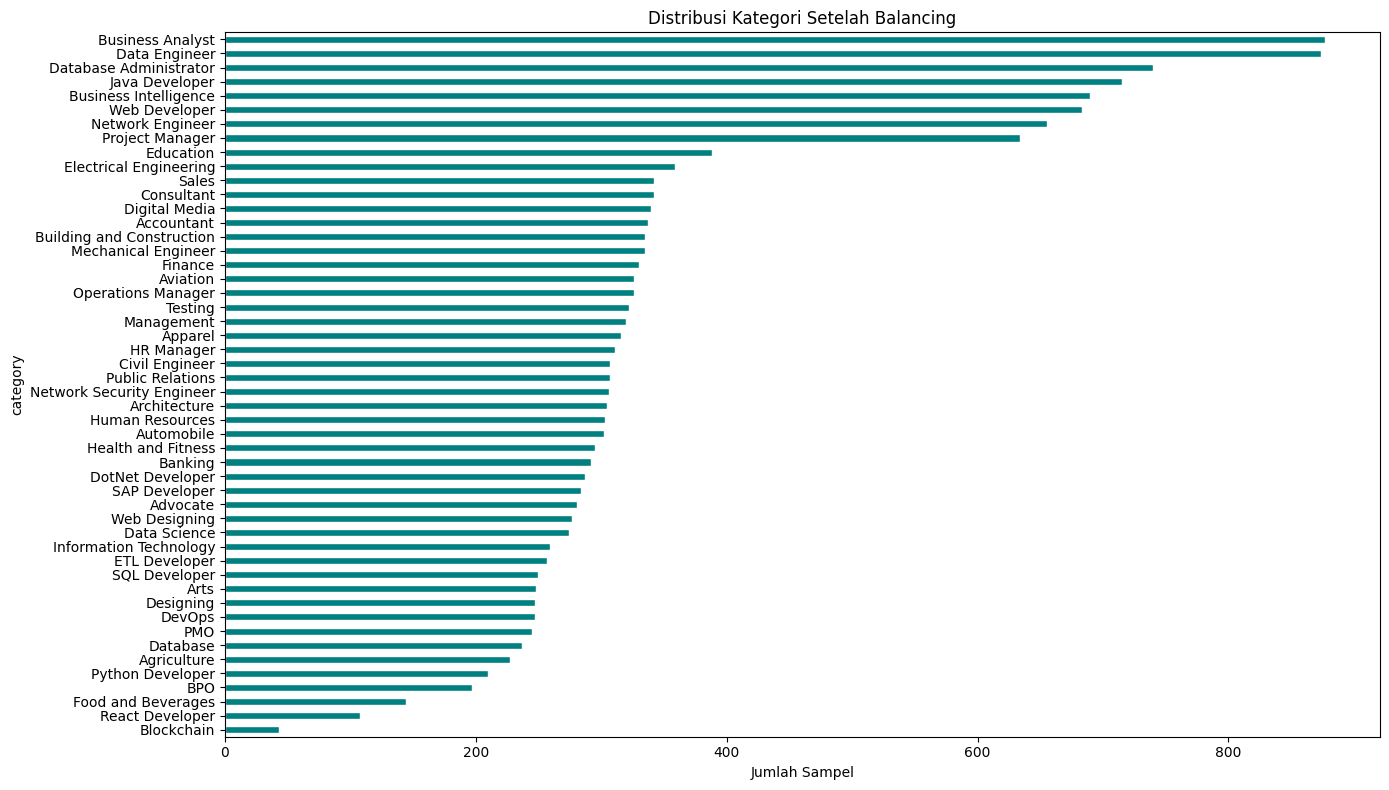

In [14]:
# Visualisasi distribusi sesudah balancing
cat_counts_bal = df_balanced['category'].value_counts()

fig, ax = plt.subplots(figsize=(14, 8))
cat_counts_bal.sort_values().plot(kind='barh', ax=ax, color='teal', edgecolor='white')
ax.set_xlabel('Jumlah Sampel')
ax.set_title('Distribusi Kategori Setelah Balancing')
plt.tight_layout()
plt.savefig('../data/merge_distribution_after.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Label Encoding

In [15]:
le = LabelEncoder()
df_balanced['label'] = le.fit_transform(df_balanced['category'])

# Simpan label encoder baru (menggantikan yang lama)
le_path = os.path.join(PROCESSED_DIR, 'label_encoder.pkl')
with open(le_path, 'wb') as f:
    pickle.dump(le, f)

print(f'Total kelas     : {len(le.classes_)}')
print()
print('Label mapping:')
for idx, cls in enumerate(le.classes_):
    count = (df_balanced['label'] == idx).sum()
    print(f'  {idx:2d} -> {cls:40s} ({count} sampel)')

print(f'\nLabel encoder disimpan ke: {le_path}')

Total kelas     : 50

Label mapping:
   0 -> Accountant                               (337 sampel)
   1 -> Advocate                                 (281 sampel)
   2 -> Agriculture                              (227 sampel)
   3 -> Apparel                                  (316 sampel)
   4 -> Architecture                             (305 sampel)
   5 -> Arts                                     (248 sampel)
   6 -> Automobile                               (302 sampel)
   7 -> Aviation                                 (326 sampel)
   8 -> BPO                                      (197 sampel)
   9 -> Banking                                  (292 sampel)
  10 -> Blockchain                               (43 sampel)
  11 -> Building and Construction                (335 sampel)
  12 -> Business Analyst                         (877 sampel)
  13 -> Business Intelligence                    (690 sampel)
  14 -> Civil Engineer                           (307 sampel)
  15 -> Consultant                

## 8. Train / Val / Test Split

In [16]:
train_df, temp_df = train_test_split(
    df_balanced,
    test_size    = 0.30,
    random_state = RANDOM_STATE,
    stratify     = df_balanced['label'],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size    = 0.50,
    random_state = RANDOM_STATE,
    stratify     = temp_df['label'],
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train : {len(train_df):,} baris ({len(train_df)/len(df_balanced)*100:.1f}%)')
print(f'Val   : {len(val_df):,} baris ({len(val_df)/len(df_balanced)*100:.1f}%)')
print(f'Test  : {len(test_df):,} baris ({len(test_df)/len(df_balanced)*100:.1f}%)')

Train : 12,345 baris (70.0%)
Val   : 2,645 baris (15.0%)
Test  : 2,646 baris (15.0%)


## 9. Simpan Output

In [ ]:
KEEP_COLS = ['clean_text', 'label', 'category']

train_df[KEEP_COLS].to_pickle(os.path.join(PROCESSED_DIR, 'train.pkl'))
val_df[KEEP_COLS].to_pickle(os.path.join(PROCESSED_DIR, 'val.pkl'))
test_df[KEEP_COLS].to_pickle(os.path.join(PROCESSED_DIR, 'test.pkl'))

# Simpan juga full merged dataset untuk referensi
df_balanced.to_csv(os.path.join(PROCESSED_DIR, 'merged_dataset.csv'), index=False)

print('File tersimpan:')
for fname in ['train.pkl', 'val.pkl', 'test.pkl', 'label_encoder.pkl', 'merged_dataset.csv']:
    fpath = os.path.join(PROCESSED_DIR, fname)
    size  = os.path.getsize(fpath) / (1024 * 1024)
    print(f'  {fname:30s} ({size:.1f} MB)')

## 10. Update NUM_LABELS untuk Notebook Selanjutnya

In [ ]:
num_labels = len(le.classes_)

print('=' * 60)
print('RINGKASAN MERGE')
print('=' * 60)
print(f"""
SUMBER DATA
  Dataset asli   : {len(df_orig):,} baris  (9 kelas IT)
  ResumeAtlas    : {len(df_atlas):,} baris  (43 kelas)

HASIL MERGE
  Total bersih   : {len(df_balanced):,} baris
  Total kelas    : {num_labels}
  Train          : {len(train_df):,} baris
  Val            : {len(val_df):,} baris
  Test           : {len(test_df):,} baris

⚠ PENTING — UPDATE DI NOTEBOOK BERIKUTNYA:
  03_tokenisasi.ipynb  → tidak perlu diubah
  04_training.ipynb    → ubah NUM_LABELS = {num_labels}
  05_evaluasi.ipynb    → ubah SHORT_LABELS (sesuai kelas baru)
  06_inference.ipynb   → ubah LABEL_MAP (sesuai kelas baru)

  Kelas-kelas baru:
""")
for idx, cls in enumerate(le.classes_):
    print(f'  {idx:2d}. {cls}')

print()
print('=' * 60)
print('Lanjut ke: 03_tokenisasi.ipynb')
print('(hapus dulu file train_dataset.pkl, val_dataset.pkl, test_dataset.pkl')
print(' dan folder models/tokenizer/ sebelum jalankan ulang tokenisasi)')

---
**Notebook ini selesai.** Output `train.pkl`, `val.pkl`, `test.pkl`, dan `label_encoder.pkl` sudah diperbarui dengan data gabungan.

Langkah selanjutnya:
1. Hapus `data/processed/train_dataset.pkl`, `val_dataset.pkl`, `test_dataset.pkl`
2. Hapus folder `models/tokenizer/`
3. Jalankan ulang `03_tokenisasi.ipynb`
4. Update `NUM_LABELS` di `04_training.ipynb`